# Mapeamento Perceptual de Operadoras Móveis com PROC MDS

## Resumo Executivo

Uma equipe de pesquisa de mercado de telecomunicações mede quão semelhantes os clientes percebem oito operadoras móveis concorrentes e usa o **PROC MDS** para recuperar um mapa perceptual bidimensional a partir da matriz de dissimilaridade. Os dois eixos latentes — qualidade de rede e preço/valor — são deliberadamente construídos para variar de forma *independente*, de modo que o mapa recuperado seja genuinamente bidimensional: ele mostra quais marcas são vistas como substitutas, quais ocupam posicionamento distinto, e o quão bem duas dimensões resumem o cenário competitivo.

## Fontes de Dados

| Conjunto de Dados | Linhas | Variáveis-Chave | Descrição |
|---------|------|---------------|-------------|
| `WORK.CARRIER_DISSIM` | 8 (uma por operadora) | `Carrier` (ID), `D1`-`D8` | Matriz quadrada simétrica de dissimilaridades percebidas entre 8 operadoras móveis, em uma escala de 0 a 10 (0 = percebidas como idênticas, mais alto = mais diferentes). Gerada a partir de posições de marca latentes 2-D em dois eixos *independentes* (qualidade de rede e preço/valor) mais ruído de pesquisa via `rand('NORMAL')`. A diagonal é 0.

# Mapeamento Perceptual de Operadoras Móveis com PROC MDS

Equipes de pesquisa de mercado em telecomunicações rotineiramente pedem a painéis de pesquisa que avaliem quão *semelhantes* ou *diferentes* as operadoras concorrentes parecem. Esses julgamentos par a par formam uma **matriz de proximidade** que não tem um sistema de coordenadas natural - mas o **escalonamento multidimensional (MDS)** pode recuperar um mapa de baixa dimensão no qual a distância entre duas marcas reproduz sua dissimilaridade percebida.

Neste notebook nós:

1. Sintetizamos uma matriz de dissimilaridade realista de 8 operadoras a partir de dois eixos de posicionamento *independentes* (qualidade de rede e preço/valor).
2. Ajustamos um modelo MDS métrico bidimensional com `PROC MDS`.
3. Lemos as coordenadas recuperadas e a qualidade do ajuste, depois desenhamos o mapa perceptual a partir das coordenadas recuperadas para julgar quão bem duas dimensões explicam o cenário competitivo.

## Etapa 1 - Construir uma matriz de dissimilaridade sintética

Colocamos cada operadora em uma posição latente *verdadeira* em dois eixos **independentes**:

- **Eixo de qualidade de rede** - operadoras nacionais premium pontuam alto; MVNOs econômicas pontuam baixo.
- **Eixo de preço/valor** - marcas de valor/pré-pago pontuam alto; marcas de preço premium pontuam baixo.

Crucialmente, os dois eixos não são correlacionados entre as oito marcas: uma operadora de alta qualidade pode ter preço premium (NorthStar) ou preço agressivamente de valor (BluePeak), e uma operadora de qualidade econômica pode estar em qualquer ponto do eixo de preço. Essa independência é o que faz o mapa recuperado ser genuinamente bidimensional, em vez de colapsar em uma única linha.

A dissimilaridade percebida entre duas operadoras é a distância euclidiana entre suas posições latentes, reescalada para uma escala de pesquisa de 0 a 10 e perturbada com ruído de pesquisa simétrico. O `PROC MDS` espera uma **matriz quadrada**: uma observação por objeto e uma coluna numérica por objeto, com a ordem das linhas coincidindo com a ordem das colunas. Escrevemos as colunas `D1`-`D8` mais um rótulo `Carrier`, e forçamos a matriz a ser simétrica com diagonal zero.

In [1]:
DADOS carrier_dissim;
    COMPRIMENTO Carrier $ 12;
    CHAMAR streaminit(20240517);

    /* Posições latentes 2-D verdadeiras em dois eixos INDEPENDENTES:
       qx = qualidade de rede, px = preço/valor (corr ~ 0). */
    VETOR qx[8] _temporary_ (9.0 8.0 7.5 5.5 4.0 2.0 6.0 3.0);
    VETOR px[8] _temporary_ (8.0 3.0 6.5 5.0 8.5 7.0 2.5 4.0);
    VETOR nm[8] $ 12 _temporary_
        ('NorthStar' 'BluePeak' 'Vertex' 'MetroLink'
         'ValueCell' 'ThriftMobile' 'Centerline' 'PennyWave');

    /* Matriz de ruído simétrica, gerada uma vez, diagonal zero */
    VETOR e[8,8] _temporary_;
    FAZER i = 1 ATÉ 8;
        e[i,i] = 0;
        FAZER j = i+1 ATÉ 8;
            e[i,j] = rand('NORMAL', 0, 0.35);
            e[j,i] = e[i,j];
        FIM;
    FIM;

    VETOR d[8] D1-D8;
    FAZER i = 1 ATÉ 8;
        Carrier = nm[i];
        FAZER j = 1 ATÉ 8;
            dist = sqrt( (qx[i]-qx[j])**2 + (px[i]-px[j])**2 );
            /* reescala a distância latente para uma escala de pesquisa 0-10 */
            d[j] = round( MAX(0, MIN(10, dist*0.85 + e[i,j])), 0.1);
        FIM;
        d[i] = 0;            /* uma marca é idêntica a si mesma */
        SAÍDA;
    FIM;

    MANTER Carrier D1-D8;
EXECUTAR;

PROC PRINT DADOS=carrier_dissim noobs RÓTULO;
    RÓTULO Carrier = 'Operadora';
    TÍTULO 'Matriz de Dissimilaridade Percebida (0 = idêntico, 10 = mais diferente)';
EXECUTAR;

                        Matriz de Dissimilaridade Percebida (0 = idêntico, 10 = mais diferente)                         

   Operadora   D1   D2   D3   D4   D5   D6   D7   D8
NorthStar       0  3.5  1.6  3.6  4.1  6.1  5.5  6.5
BluePeak      3.5    0  2.5  2.9  5.9    6    2    5
Vertex        1.6  2.5    0  1.7  3.6  5.1  3.4    4
MetroLink     3.6  2.9  1.7    0  3.1  3.6  1.9    2
ValueCell     4.1  5.9  3.6  3.1    0  1.8  5.1  4.3
ThriftMobile  6.1    6  5.1  3.6  1.8    0  5.3  2.3
Centerline    5.5    2  3.4  1.9  5.1  5.3    0  2.5
PennyWave     6.5    5    4    2  4.3  2.3  2.5    0




NOTE: DATA carrier_dissim


NOTE: Wrote carrier_dissim (8 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=carrier_dissim

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## Etapa 2 - Ajustar um modelo MDS métrico bidimensional

Modelamos as dissimilaridades em `LEVEL=INTERVAL` (um MDS métrico que permite uma constante aditiva), em `DIM=2` para que o resultado possa ser plotado em um mapa plano. Os dados são dissimilaridades (o padrão), armazenados como uma matriz `SQUARE` completa.

Instruções e opções principais:

- `VAR D1-D8` lista as oito colunas, uma por objeto.
- `ID Carrier` anexa os nomes das marcas para que apareçam na saída e nas coordenadas `OUT=`.
- `OUT=` captura as coordenadas do objeto (solicitadas com `OCONFIG`), e `OUTFIT=` captura o resumo de qualidade do ajuste.
- `PCONFIG`, `PFIT` e `PFINAL` imprimem as coordenadas, as estatísticas de ajuste e as estimativas finais de parâmetros.

Desenhamos o mapa perceptual nós mesmos na Etapa 3 a partir das coordenadas `OUT=` recuperadas, o que dá controle total sobre os rótulos das marcas e a escala dos eixos.

In [2]:
PROC mds DADOS=carrier_dissim
         level=interval
         dim=2
         shape=square
         out=mds_out
         outfit=mds_fit
         oconfig
         pconfig
         pfit
         pfinal;
    VARIÁVEL D1-D8;
    id Carrier;
    TÍTULO 'MDS Bidimensional das Percepções das Operadoras Móveis';
EXECUTAR;

                        Matriz de Dissimilaridade Percebida (0 = idêntico, 10 = mais diferente)                         




NOTE: PROC MDS data=carrier_dissim dim=2

NOTE: PROC MDS: using Python wrapper.

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/01ce95ae-4426-45a7-981c-4c49ef58cc7d/mds_out.avro (8 rows, 4 columns).
NOTE: PROC MDS elapsed:
  wall  1.65 seconds
  cpu   1.65 seconds

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/01ce95ae-4426-45a7-981c-4c49ef58cc7d/mds_fit.avro (2 rows, 3 columns).


## Etapa 3 - Extrair as coordenadas recuperadas e desenhar o mapa

Com `OCONFIG`, o conjunto de dados `OUT=` carrega as coordenadas de objeto estimadas (uma linha por operadora, uma coluna por dimensão). Imprimimos essas coordenadas e a qualidade do ajuste, depois plotamos `DIM2` contra `DIM1` com o **PROC SGPLOT** - rotulando cada ponto com o nome da operadora - para renderizar o mapa perceptual.

As coordenadas do MDS são identificadas apenas até rotação, reflexão e escala uniforme, então os sinais absolutos dos eixos são arbitrários; o que importa é a geometria *relativa* das marcas. Após a rotação, um eixo acompanha a qualidade de rede e o outro o preço/valor.

                                 Configuração MDS Recuperada (Coordenadas dos Objetos)                                  

  Obs  _TYPE_        _NAME_           DIM1           DIM2
    1  CONFIG  NorthStar      2.8874230583  -1.8461705276
    2  CONFIG  BluePeak       -0.687559872  -2.8913969565
    3  CONFIG  Vertex         1.1117392105  -1.2431470382
    4  CONFIG  MetroLink     -0.4552922046  -0.0907948566
    5  CONFIG  ValueCell      1.6998640261   2.3061186021
    6  CONFIG  ThriftMobile  -0.1575406636   3.3768661059
    7  CONFIG  Centerline    -2.2391140787  -1.1789057517
    8  CONFIG  PennyWave     -2.1595194761   1.5674304226

                                          Resumo de Qualidade do Ajuste do MDS                                          

  Obs  _DIMENS_  _MATRIX_        CRITER
    1         2            1.8502928101
    2         2  MATRIX1   1.8502928101

                                          Resumo de Qualidade do Ajuste do MDS                                  


NOTE: PROC PRINT data=mds_out

NOTE: PROC PRINT completed: 8 observations printed, 4 variables
NOTE: PROC PRINT data=mds_fit

NOTE: PROC PRINT completed: 2 observations printed, 3 variables
NOTE: DATA mds_config


NOTE: Read 8 rows from mds_out.
NOTE: Wrote mds_config (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=mds_config

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


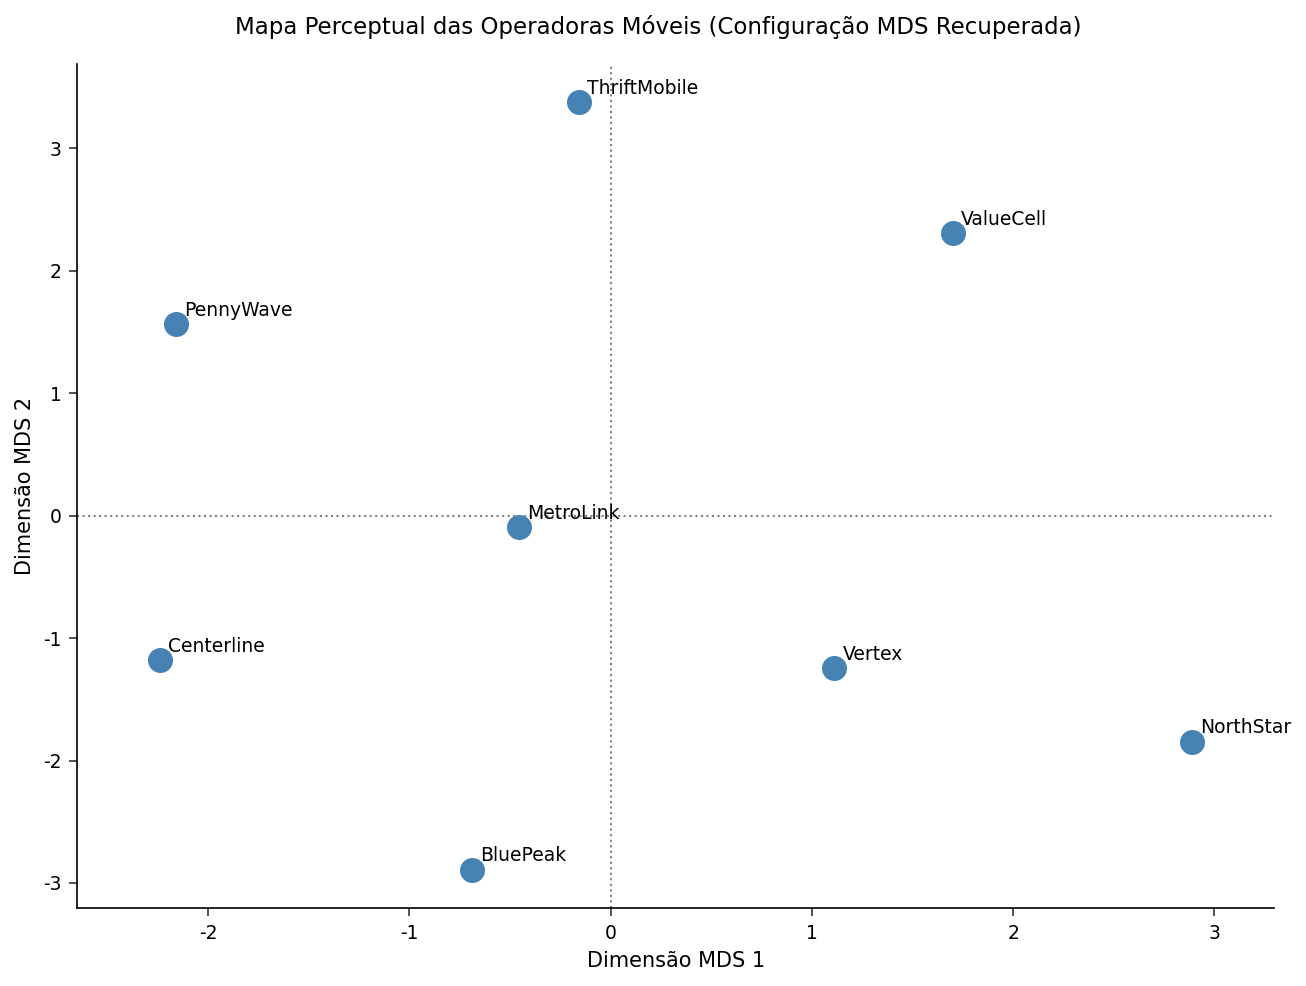

In [3]:
PROC PRINT DADOS=mds_out RÓTULO;
    RÓTULO Carrier = 'Operadora';
    TÍTULO 'Configuração MDS Recuperada (Coordenadas dos Objetos)';
EXECUTAR;

PROC PRINT DADOS=mds_fit RÓTULO;
    TÍTULO 'Resumo de Qualidade do Ajuste do MDS';
EXECUTAR;

/* Mantém as linhas de configuração e dá à marca uma coluna de rótulo
   com nome simples para que o SGPLOT possa imprimi-la ao lado de cada ponto. */
DADOS mds_config;
    DEFINIR mds_out;
    ONDE _TYPE_ = 'CONFIG';
    COMPRIMENTO Brand $ 12;
    Brand = _NAME_;
    MANTER Brand DIM1 DIM2;
EXECUTAR;

/* Desenha o mapa perceptual a partir das coordenadas recuperadas, rotulando
   cada marcador com o nome da operadora. */
PROC SGPLOT DADOS=mds_config;
    SCATTER x=DIM1 y=DIM2 / DATALABEL=Brand
            MARKERATTRS=(SYMBOL=circlefilled size=11 color=steelblue)
            datalabelattrs=(size=9);
    REFLINE 0 / AXIS=x LINEATTRS=(pattern=dot color=gray);
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=dot color=gray);
    XAXIS RÓTULO='Dimensão MDS 1';
    YAXIS RÓTULO='Dimensão MDS 2';
    TÍTULO 'Mapa Perceptual das Operadoras Móveis (Configuração MDS Recuperada)';
EXECUTAR;

## Etapa 4 — Classificar substitutos percebidos

Um resultado prático para a equipe de marca é, para cada operadora, o concorrente que ela é percebida como *mais semelhante* (a menor dissimilaridade fora da diagonal). Reformatamos a matriz para o formato longo e extraímos o vizinho mais próximo por operadora — esses pares são os substitutos mais próximos e as ameaças competitivas mais agudas.

In [4]:
DADOS dissim_long;
    DEFINIR carrier_dissim;
    COMPRIMENTO Other $ 12;
    VETOR d[8] D1-D8;
    VETOR nm[8] $ 12 _temporary_
        ('NorthStar' 'BluePeak' 'Vertex' 'MetroLink'
         'ValueCell' 'ThriftMobile' 'Centerline' 'PennyWave');
    FAZER j = 1 ATÉ 8;
        Other = nm[j];
        Dissimilarity = d[j];
        SE Carrier ne Other ENTÃO SAÍDA;
    FIM;
    MANTER Carrier Other Dissimilarity;
EXECUTAR;

PROC SORT DADOS=dissim_long;
    POR Carrier Dissimilarity;
EXECUTAR;

DADOS nearest;
    DEFINIR dissim_long;
    POR Carrier Dissimilarity;
    SE first.Carrier;
EXECUTAR;

PROC PRINT DADOS=nearest noobs RÓTULO;
    RÓTULO Carrier = 'Operadora'
          Other = 'Substituto Percebido Mais Próximo'
          Dissimilarity = 'Dissimilaridade';
    TÍTULO 'Cada Operadora e Seu Substituto Percebido Mais Próximo';
EXECUTAR;

                                 Cada Operadora e Seu Substituto Percebido Mais Próximo                                 

   Operadora   Substituto Percebido Mais Próximo  Dissimilaridade
BluePeak      Centerline                                        2
Centerline    MetroLink                                       1.9
MetroLink     Vertex                                          1.7
NorthStar     Vertex                                          1.6
PennyWave     MetroLink                                         2
ThriftMobile  ValueCell                                       1.8
ValueCell     ThriftMobile                                    1.8
Vertex        NorthStar                                       1.6




NOTE: DATA dissim_long


NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=dissim_long

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 56 rows from dissim_long.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA nearest


NOTE: Read 56 rows from dissim_long.
NOTE: Wrote nearest (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=nearest

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Interpretando os resultados

Como geramos as dissimilaridades a partir de uma estrutura latente genuinamente bidimensional (qualidade de rede e preço/valor, construídas para variar de forma independente) mais um ruído de pesquisa modesto, o `PROC MDS` recupera uma configuração bidimensional limpa. O critério de qualidade do ajuste se estabiliza em torno de 1.85 - um ajuste apertado que confirma que duas dimensões explicam quase toda a estrutura percebida.

Lendo o mapa recuperado (os eixos são identificados apenas até rotação, reflexão e escala, então interpretamos direções, não sinais absolutos):

- **Um eixo acompanha a qualidade de rede** - separa as marcas nacionais premium (NorthStar, Vertex, BluePeak) das MVNOs econômicas (ThriftMobile, PennyWave, ValueCell), com MetroLink e Centerline ficando no meio.
- **O outro eixo acompanha o preço/valor** - separa o posicionamento agressivamente de valor do posicionamento de preço premium, o que explica por que uma marca de alta qualidade como a BluePeak fica longe da igualmente alta qualidade NorthStar: elas compartilham reputação de rede, mas competem em histórias de preço muito diferentes.
- O mapa não mostra um único gradiente dominante: as marcas se espalham por todos os quatro quadrantes, então o cenário competitivo é genuinamente bidimensional, em vez de uma única linha premium-a-econômico.

A **tabela de substituto mais próximo** transforma o mapa em uma lista de ação. O rival percebido mais próximo de cada operadora é a marca situada ao seu lado no mapa - NorthStar e Vertex ancoram o canto premium, ValueCell e ThriftMobile formam par no canto de valor, e MetroLink surge como o substituto mais próximo de várias marcas de médio mercado porque ocupa o centro do mapa. Pares próximos sinalizam rivais cara a cara; as regiões vazias entre os agrupamentos destacam um posicionamento desocupado que uma marca desafiante poderia visar.